In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
import globals.path as pth
import globals.imaging as im
import globals.design as dn
import matplotlib.ticker as mticker
import PcmPy as pcm
import pandas as pd
import seaborn as sb
from vis import lineplot_roi_avg
from util.util import get_trained_and_untrained

figDir = pth.figDir

plt.style.use('default')

In [8]:
rois = im.rois['ROI'][:-1]
sessions = [3, 9, 23]
H = 'L'
glm= 1

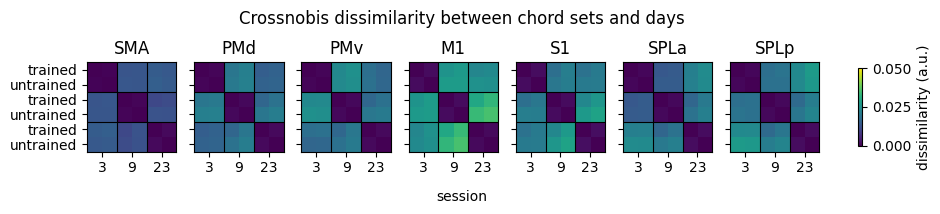

In [9]:
fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(10, 2))

vmin, vmax = 0, .05

for r, roi in enumerate(rois):
    ax = axs[r]
    G = np.load(os.path.join(pth.baseDir, pth.pcmDir, f'G_obs.trained-untrained.glm{glm}.{H}.{roi}.npy'))
    D = pcm.G_to_dist(G)
    ax.imshow(D.mean(axis=0), vmin=vmin, vmax=vmax)
    ax.set_title(roi)
    ax.set_xticks([.5, 2.5, 4.5])
    ax.set_xticklabels(sessions)
    ax.set_yticks(np.arange(6))
    ax.set_yticklabels(['trained', 'untrained'] * 3)
    ax.axhline(1.5, color='k', lw=.8)
    ax.axhline(3.5, color='k', lw=.8)
    ax.axvline(1.5, color='k', lw=.8)
    ax.axvline(3.5, color='k', lw=.8)

fig.supxlabel('session', fontsize=10)

cax = ax.get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.005)
cbar.set_label('dissimilarity (a.u.)')

fig.suptitle('Crossnobis dissimilarity between chord sets and days')

plt.show()

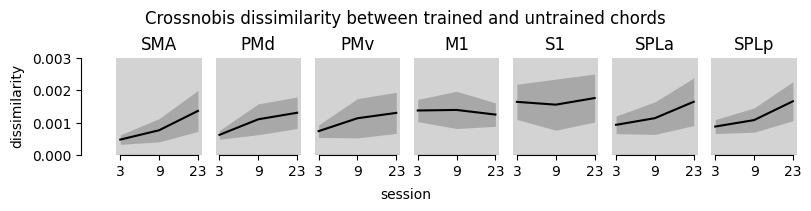

In [10]:
dist = {'dist': [], 'session': [], 'sn': [], 'roi': [], 'Hem': []}
for r, roi in enumerate(rois):
    G = np.load(os.path.join(pth.baseDir, pth.pcmDir, f'G_obs.trained-untrained.glm{glm}.{H}.{roi}.npy'))
    D = pcm.G_to_dist(G)
    for I, i in enumerate(np.arange(1, 6, 2)):
        dist_tmp = D[:, i-1, i]
        dist['dist'].extend(dist_tmp)
        dist['session'].extend(np.repeat(sessions[I], dist_tmp.size))
        dist['sn'].extend(np.arange(dist_tmp.size))
        dist['roi'].extend([roi] * dist_tmp.size)
        dist['Hem'].extend([H] * dist_tmp.size)

df = pd.DataFrame(dist)
fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(8, 2), constrained_layout=True)
fig, axs = lineplot_roi_avg(fig, axs, df, metric='dist', H='L', rois=rois, color='k')
axs[0].set_ylim([0, .003])
fig.supxlabel('session', fontsize=10)
fig.supylabel('dissimilarity', fontsize=10)
fig.suptitle('Crossnobis dissimilarity between trained and untrained chords')

plt.show()

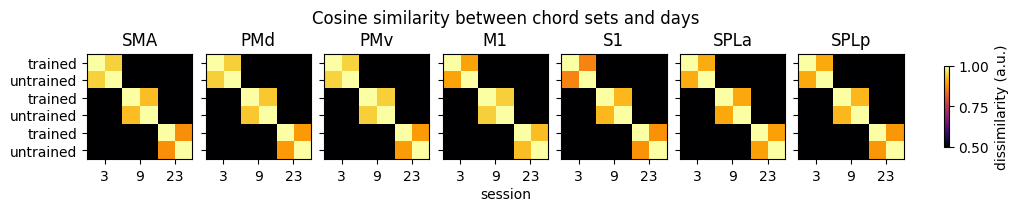

In [11]:
fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(10, 2), constrained_layout=True)

vmin, vmax = .5, 1

for r, roi in enumerate(rois):
    ax = axs[r]
    G = np.load(os.path.join(pth.baseDir, pth.pcmDir, f'G_obs.trained-untrained.glm{glm}.{H}.{roi}.npy'))
    D = pcm.G_to_cosine(G)
    ax.imshow(D.mean(axis=0), vmin=vmin, vmax=vmax, cmap='inferno')
    ax.set_title(roi)
    ax.set_xticks([.5, 2.5, 4.5])
    ax.set_xticklabels([3, 9, 23])
    ax.set_yticks(np.arange(6))
    ax.set_yticklabels(['trained', 'untrained'] * 3)

fig.supxlabel('session', fontsize=10)

cax = ax.get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.005)
cbar.set_label('dissimilarity (a.u.)')

fig.suptitle('Cosine similarity between chord sets and days')

plt.show()

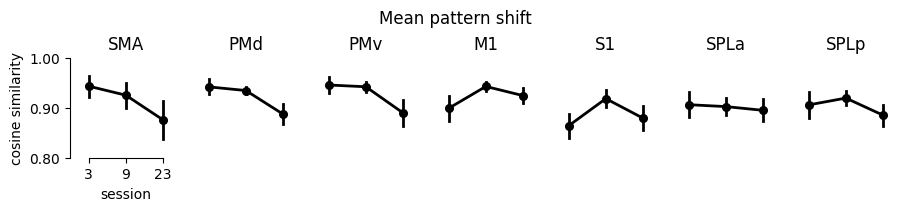

In [12]:
cos = {'cos': [], 'session': [], 'sn': [], 'roi': [], 'Hem': []}
for r, roi in enumerate(rois):
    G = np.load(os.path.join(pth.baseDir, pth.pcmDir, f'G_obs.trained-untrained.glm{glm}.{H}.{roi}.npy'))
    D = pcm.G_to_cosine(G)
    for I, i in enumerate(np.arange(1, 6, 2)):
        cos_tmp = D[:, i-1, i]
        cos['cos'].extend(cos_tmp)
        cos['session'].extend(np.repeat(sessions[I], cos_tmp.size))
        cos['sn'].extend(np.arange(cos_tmp.size))
        cos['roi'].extend([roi] * cos_tmp.size)
        cos['Hem'].extend([H] * cos_tmp.size)
df = pd.DataFrame(cos)

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(9, 2), constrained_layout=True)
for r, roi in enumerate(rois):
    ax = axs[r]
    sb.pointplot(data=df[df.roi==roi], ax=ax, x='session', y='cos', color='k', lw=2, errorbar='se')
    ax.set_xlabel(None)
    ax.set_ylim([.8, 1])
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines['bottom'].set_bounds(0, 2)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    #ax.spines['left'].set_bounds(0, 4)
    ax.spines[['left', 'bottom']].set_visible(False) if r>0 else None
    ax.tick_params(left=False, bottom=False, labelbottom=False) if r>0 else None
    ax.set_title(roi)
    ax.axhline(0, lw=.8, color='k', ls=':')
#axs[0].set_ylim((-.5, 5.5))
axs[0].set_ylabel('cosine similarity')
axs[0].set_xlabel('session')
fig.suptitle('Mean pattern shift')
fig.savefig(os.path.join(figDir, f'mean_shift.ROI.glm{glm}.pdf'))

plt.show()

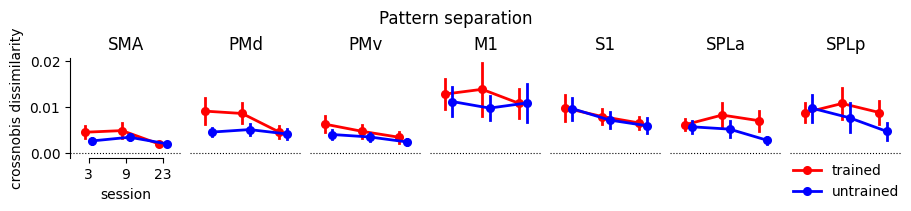

In [22]:
dist = {'dist': [], 'chord': [], 'session': [], 'sn': [], 'roi': [], 'Hem': []}
for r, roi in enumerate(rois):
    for s, sess in enumerate(sessions):
        G = np.load(os.path.join(pth.baseDir, pth.pcmDir, f'G_obs.chord.glm{glm}.{H}.{roi}.npy'))
        D = pcm.G_to_dist(G[:, s] ) #/ np.trace(G))
        trained = D[:, :4, :4].mean(axis=(1, 2))
        untrained = D[:, 4:, 4:].mean(axis=(1, 2))
        dist_tmp = np.r_[trained, untrained]
        dist['dist'].extend(dist_tmp)
        dist['chord'].extend(['trained'] * trained.size + ['untrained'] * trained.size)
        dist['session'].extend([sess] * dist_tmp.size)
        dist['sn'].extend(np.arange(dist_tmp.size))
        dist['roi'].extend([roi] * dist_tmp.size)
        dist['Hem'].extend([H] * dist_tmp.size)
df = pd.DataFrame(dist)

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(9, 2), constrained_layout=True)
for r, roi in enumerate(rois):
    ax = axs[r]
    sb.pointplot(data=df[df.roi==roi], ax=ax, x='session', y='dist', hue='chord', hue_order=['trained', 'untrained'], palette=['red', 'blue'], dodge=.2,lw=2,
                 legend=False if r<len(rois)-1 else True,
                 errorbar='se')
    ax.set_xlabel(None)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines['bottom'].set_bounds(0, 2)
    #ax.spines['left'].set_bounds(0, 4)
    ax.spines[['left', 'bottom']].set_visible(False) if r>0 else None
    ax.tick_params(left=False, bottom=False, labelbottom=False) if r>0 else None
    ax.set_title(roi)
    ax.axhline(0, lw=.8, color='k', ls=':')
#axs[0].set_ylim((-.5, 5.5))
axs[0].set_ylabel('crossnobis dissimilarity')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')# bbox_to_anchor=(1, .5), loc='center left')
axs[0].set_xlabel('session')
fig.suptitle('Pattern separation')
fig.savefig(os.path.join(figDir, f'pattern_separation.ROI.glm{glm}.pdf'))
plt.show()

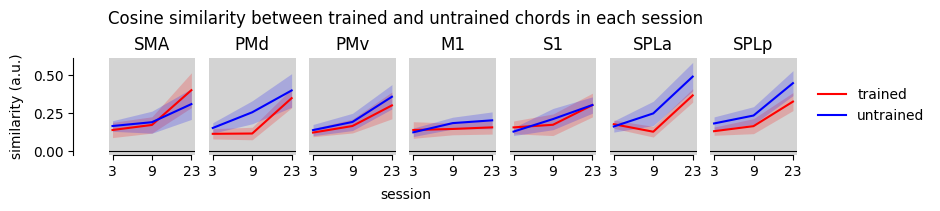

In [38]:
dist = {'cos': [], 'chord': [], 'session': [], 'sn': [], 'roi': [], 'Hem': []}
for r, roi in enumerate(rois):
    for s, sess in enumerate(sessions):
        G = np.load(os.path.join(pth.baseDir, pth.pcmDir, f'G_obs.chord.glm{glm}.{H}.{roi}.npy'))
        D = pcm.G_to_cosine(G[:, s] ) #/ np.trace(G))
        trained = D[:, :4, :4].mean(axis=(1, 2))
        untrained = D[:, 4:, 4:].mean(axis=(1, 2))
        dist_tmp = np.r_[trained, untrained]
        dist['cos'].extend(dist_tmp)
        dist['chord'].extend(['trained'] * trained.size + ['untrained'] * trained.size)
        dist['session'].extend([sess] * dist_tmp.size)
        dist['sn'].extend(np.arange(dist_tmp.size))
        dist['roi'].extend([roi] * dist_tmp.size)
        dist['Hem'].extend([H] * dist_tmp.size)

df = pd.DataFrame(dist)
fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(8, 2), constrained_layout=True)
fig, axs = lineplot_roi_avg(fig, axs, df.copy(), metric='cos', H='L', rois=rois, hue='chord', hue_order=['trained', 'untrained'], color=['red', 'blue'], label=['trained', 'untrained'])
#axs[0].set_ylim([0, .015])
fig.supxlabel('session', fontsize=10)
fig.supylabel('similarity (a.u.)', fontsize=10)
fig.suptitle('Cosine similarity between trained and untrained chords in each session')

plt.show()

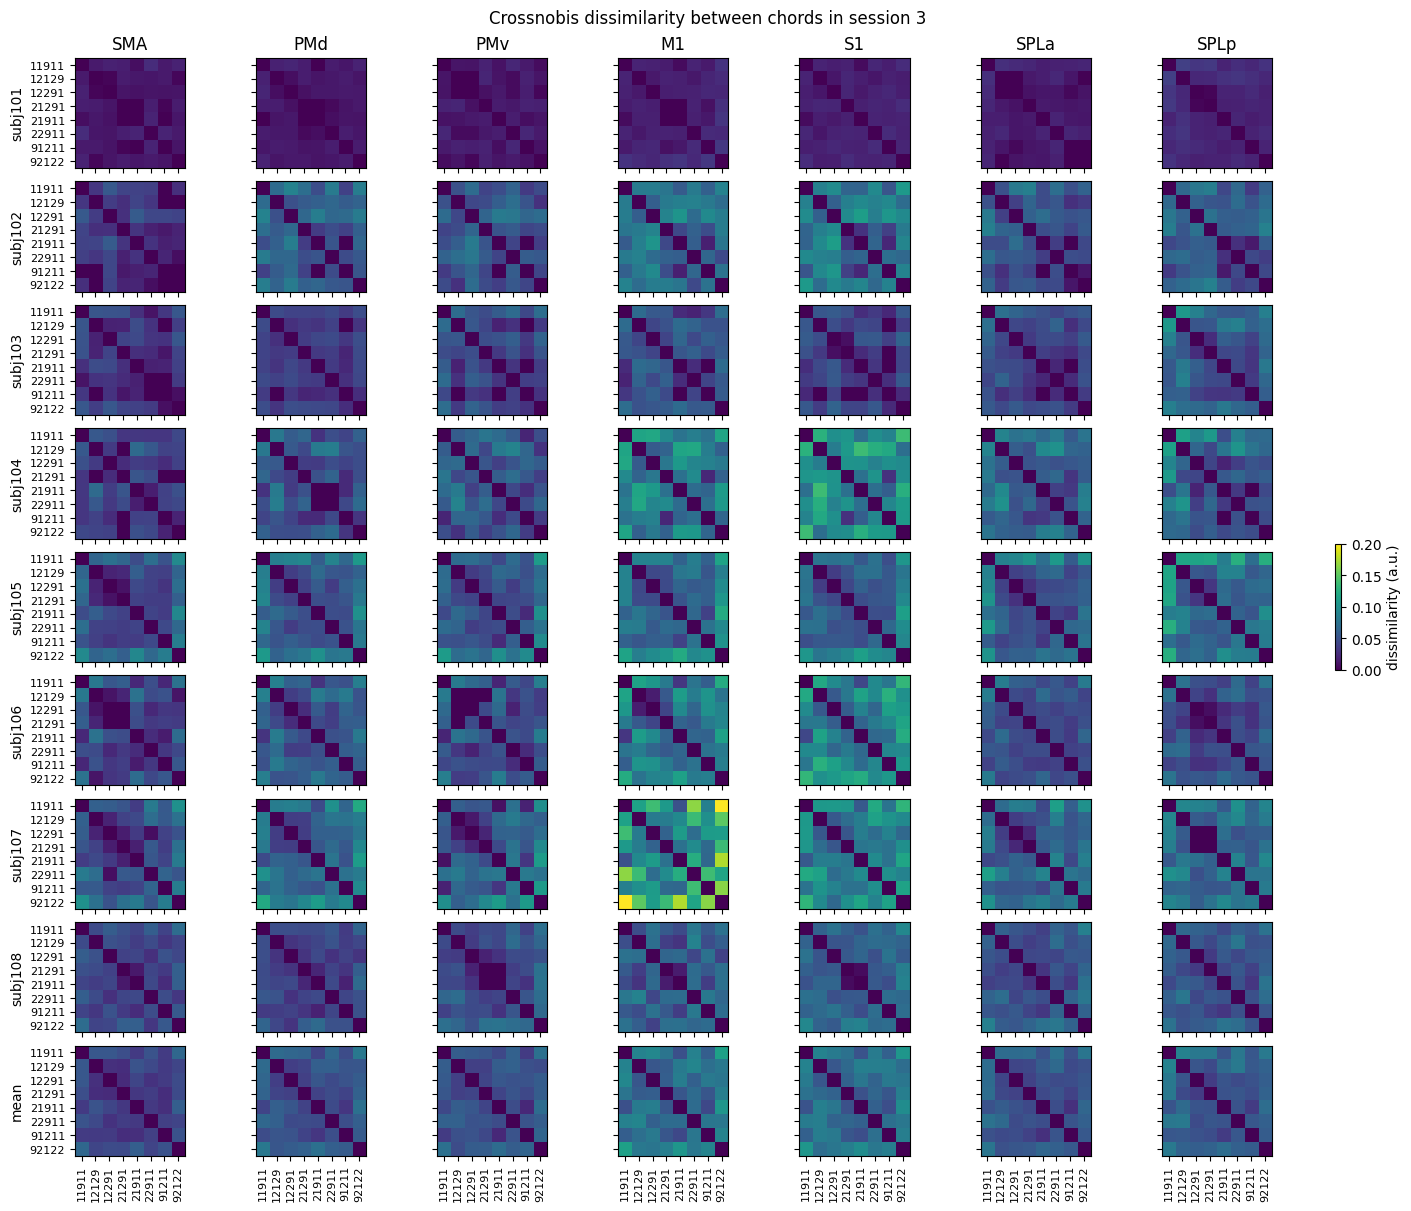

In [42]:
N = 8
participant_id = [101, 102, 103, 104, 105, 106, 107, 108]
chordID = [str(ch) for ch in dn.chordID]

fig, axs = plt.subplots(N + 1, len(rois), sharex=True, sharey=True, figsize=(14, 12), constrained_layout=True)

sess = 3
vmin, vmax = 0, .2
for r, roi in enumerate(rois):
    G = np.load(os.path.join(pth.baseDir, pth.pcmDir, f'G_obs.chord-session.glm{glm}.{H}.{roi}.npy'))
    D = pcm.G_to_dist(G[:, 0]) # / np.trace(G))
    Dd = np.zeros_like(D)
    for i in range(N):
        trained_untrained = get_trained_and_untrained(participant_id[i])
        order = [trained_untrained.index(ch) for ch in chordID]
        Dd_tmp = D[i].copy()
        Dd_tmp = Dd_tmp[np.ix_(order, order)]
        Dd[i] = Dd_tmp
        ax = axs[i, r]
        Dd_tmp = np.sign(Dd_tmp) * np.sqrt(np.abs(Dd_tmp))
        ax.imshow(Dd_tmp, vmin=vmin, vmax=vmax)
        ax.set_yticks(np.arange(8))
        ax.set_yticklabels(dn.chordID, fontsize=8)
        ax.set_ylabel(f'subj{i + 101}') if r==0 else None
    Dd_m = Dd.mean(axis=0)
    Dd_m = np.sign(Dd_m) * np.sqrt(np.abs(Dd_m))
    axs[-1, r].imshow(Dd_m, vmin=vmin, vmax=vmax)
    axs[-1, r].set_xticks(np.arange(8))
    axs[-1, r].set_xticklabels(dn.chordID, rotation=90, fontsize=8)
    axs[-1, r].set_yticks(np.arange(8))
    axs[-1, r].set_yticklabels(dn.chordID, fontsize=8)
    axs[-1, r].set_ylabel(f'mean') if r==0 else None
    axs[0, r].set_title(roi)

cax = ax.get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.005)
cbar.set_label('dissimilarity (a.u.)')

fig.suptitle(f'Crossnobis dissimilarity between chords in session {sess}')
#fig.subplots_adjust(right=.85)

plt.show()